In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigh
from scipy.stats import pearsonr



# start with some U_true and make it arrange.logpi

In [32]:
height = 30
width = 30
K_main = 5
K_subparcels = 5
K_total = 25

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=25, P=grid.P)
centroids = [(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [33]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [35]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

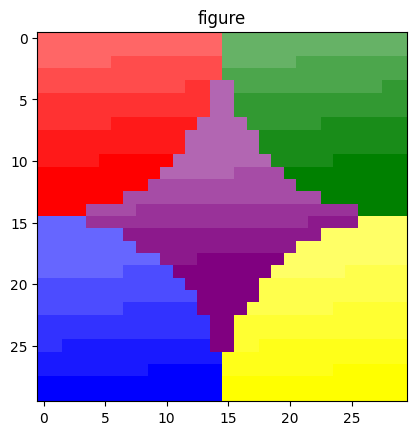

In [36]:
U_true_25 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_25 = pt.tensor(U_true_25, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_25)

plot_Us(U_true_25)

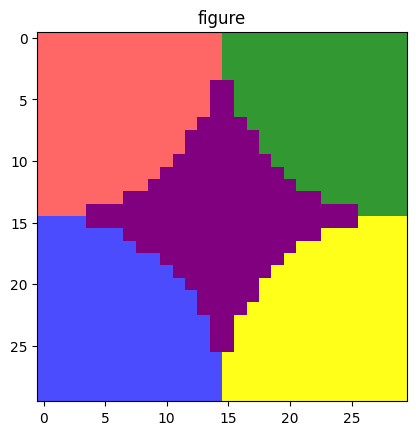

In [37]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, 1)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)

plot_Us(U_true_5)

# Make Vs based on a task covariance + parcel covariance

Covarince across parcels R

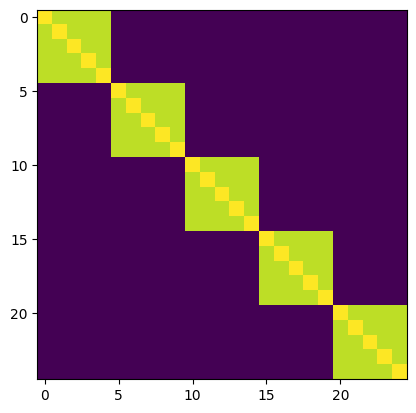

In [12]:
R= sim.custom_R(K_total =25, group_size=5, base_parcel_correlation=0.5, sub_parcel_extra_correlation=0.45)
plt.imshow(R)


covariance across tasks G

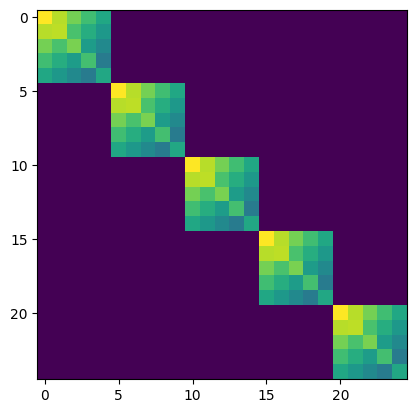

In [13]:
G = sim.custom_G(n_tasks=25, n_groups=5, group_size=5, target_corr=0.99, variance_factors=[1.0, 0.9,0.8, 0.7, 0.6])
plt.imshow(G)

make Vs (this num_iter gives a good V)

17.61365216826298
15.202629408012854
15.171034613279945
14.65178828027078
14.550428466507428
14.271245668305607
14.268131317850976
14.19471903564374


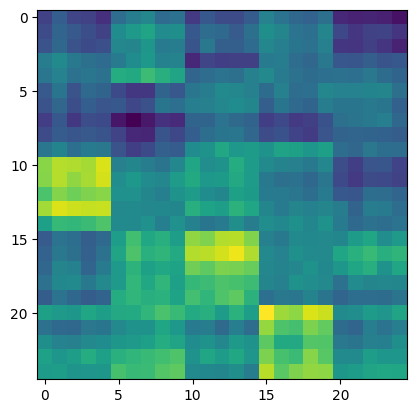

In [15]:
Vs_25= sim.find_best_V(G=G,R=R,num_iter=16000,rng = np.random.default_rng(101))
plt.imshow(Vs_25)


check covariance across rows and columns

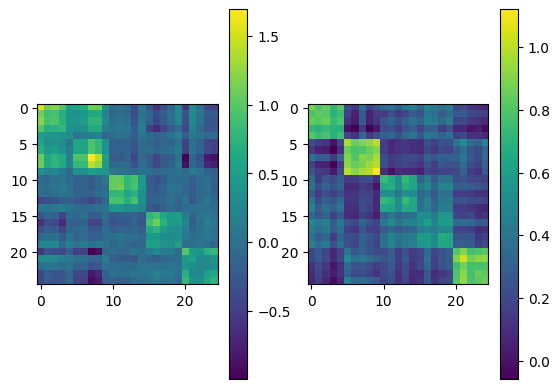

In [10]:
plt.subplot(1, 2, 1)
plt.imshow(Vs_25 @ Vs_25.T, cmap='viridis')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(Vs_25.T @ Vs_25, cmap='viridis')
plt.colorbar()
plt.show()


lower dimensional Vs (just for the 5 main parcels)

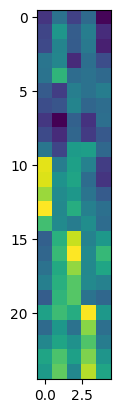

In [16]:
Vs_5 = Vs_25.reshape(25, 5, 5).mean(axis=2)
plt.imshow(Vs_5)

make true data, add noise (check how much to add based on reconstruction)

In [ ]:
noise = 0.04
Y_true = Vs_25 @ np.array(U_true_25)
Y_true_noisy = Y_true + np.random.normal(0, noise, Y_true.shape)

# U_test = sim.estimate_Us_ols(Y_true_noisy, Vs_25,regularize=None)
# max_indices = np.argmax(U_test, axis=0)
# U_hat_one_hot = np.zeros_like(U_test)
# U_hat_one_hot[max_indices, np.arange(U_test.shape[1])] = 1

(25, 900)

make test data for predicition error analysis, interested in parcel index 4 (5ith parcel, hence use it and predict tasks that activate it)

In [22]:
Y_test_noisy  = Y_true[20:,:] + np.random.normal(0, noise, Y_true[20:,:].shape)
Y_test_noisy = pt.tensor(Y_test_noisy, dtype=pt.float32)
# we'll test task profile for the last parcel only
V_test = Vs_5[20:,4]
V_test = pt.tensor(V_test, dtype=pt.float32)
if len(V_test.shape) == 1:
    V_test = V_test.reshape((5,1))


G matrix used for eigenmetrics

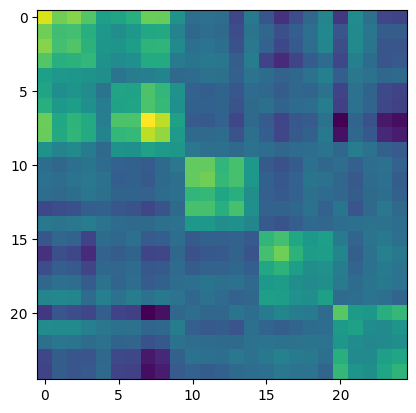

In [ ]:
# Library should be based on true Y 
G_lib  = Y_true @ Y_true.T
G_lib = np.array(G_lib)
plt.imshow(G_lib)

# Build combination dataframe

In [ ]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D = ut.build_combinations(G_lib, strategy='random',offs = offsets,n_iter=10000,n_tasks=8,seed=502)


building0


In [27]:
D

,offset,max_var,max_var_2,min_est,log_det,eigenvalues,n_tasks,combination,has_repeats,n_unique
0,1.000000e-10,2.111427e+02,2.484117e+02,6.761988e+00,12.496024,"[92.24535671994404, 67.17409202667278, 45.4298...",8,"[19, 24, 0, 13, 21, 20, 16, 17]",0,8
1,1.000000e-08,2.111427e+02,2.484117e+02,6.761988e+00,12.496024,"[92.24535672984403, 67.17409203657277, 45.4298...",8,"[19, 24, 0, 13, 21, 20, 16, 17]",0,8
2,1.000000e-06,2.111427e+02,2.484117e+02,6.761968e+00,12.496031,"[92.24535771984404, 67.17409302657278, 45.4298...",8,"[19, 24, 0, 13, 21, 20, 16, 17]",0,8
3,1.000000e-04,2.111434e+02,2.484125e+02,6.759987e+00,12.496700,"[92.24545671984404, 67.17419202657278, 45.4299...",8,"[19, 24, 0, 13, 21, 20, 16, 17]",0,8
4,1.000000e-02,2.112127e+02,2.484917e+02,6.568555e+00,12.562666,"[92.25535671984404, 67.18409202657278, 45.4398...",8,"[19, 24, 0, 13, 21, 20, 16, 17]",0,8
...,...,...,...,...,...,...,...,...,...,...
6,1.000000e+02,9.123095e+02,1.045041e+03,5.880313e-02,33.737163,"[230.75076124259184, 161.84849203589818, 117.4...",8,"[1, 23, 7, 13, 23, 6, 12, 11]",1,7
7,1.000000e+04,7.021231e+04,8.024504e+04,6.978979e-04,64.493508,"[10130.750761242592, 10061.848492035899, 10017...",8,"[1, 23, 7, 13, 23, 6, 12, 11]",1,7
8,1.000000e+06,7.000212e+06,8.000245e+06,6.999788e-06,96.708786,"[1000130.7507612426, 1000061.8484920359, 10000...",8,"[1, 23, 7, 13, 23, 6, 12, 11]",1,7
9,1.000000e+08,7.000002e+08,8.000002e+08,6.999998e-08,128.944767,"[100000130.75076124, 100000061.84849204, 10000...",8,"[1, 23, 7, 13, 23, 6, 12, 11]",1,7


In [29]:
D,Us = ev.evaluate_dataframe_simulation(D,Y_true_noisy, Vs_5, U_true_5,Y_test_noisy,V_test,parcels_to_evaluate=[4],estimation_method='projection')

Processing combination: 0
Processing combination: 100
Processing combination: 200
Processing combination: 300
Processing combination: 400
Processing combination: 500
Processing combination: 600
Processing combination: 700
Processing combination: 800
Processing combination: 900
Processing combination: 1000
Processing combination: 1100
Processing combination: 1200
Processing combination: 1300
Processing combination: 1400
Processing combination: 1500
Processing combination: 1600
Processing combination: 1700
Processing combination: 1800
Processing combination: 1900
Processing combination: 2000
Processing combination: 2100
Processing combination: 2200
Processing combination: 2300
Processing combination: 2400
Processing combination: 2500
Processing combination: 2600
Processing combination: 2700
Processing combination: 2800
Processing combination: 2900
Processing combination: 3000
Processing combination: 3100
Processing combination: 3200
Processing combination: 3300
Processing combination: 34

check correlation of eigenmetrics with MSE between U hat and U true, and check cos error between test data and reconstructed test data using test vs and U hat

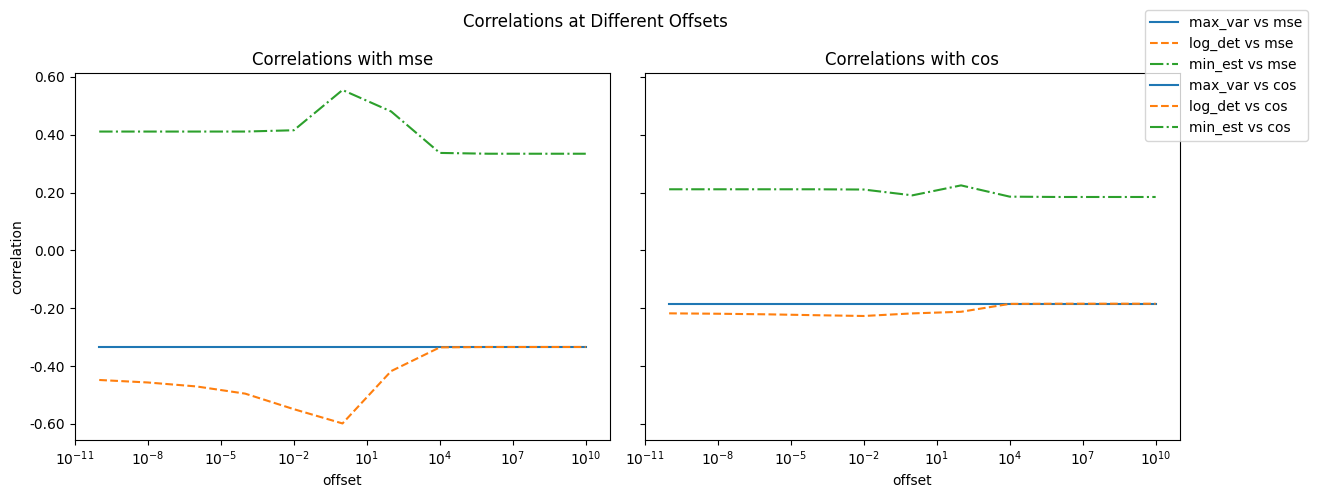

In [30]:
plot.plot_correlations(D,['max_var','log_det','min_est'],['mse','cos'])

evaluate traditional battery (single contrast), different thresholds

In [31]:
traditional_battery = ut.traditional_battery(Vs_5,[4],8)
print(traditional_battery)
mse_trad,cos_trad,U_traditional  = ev.evaluate_single_simulation(traditional_battery,Y_true_noisy, Vs_5, U_true_5,Y_test_noisy,V_test,parcels_to_evaluate=[4],
                                                       estimation_method='projection')

(7, 10, 7, 10, 7, 10, 7, 10)


plot traditional battery U hat - seems to get all of parcel 5 but also labels outside pixels as parcel 5. Thresholding problem

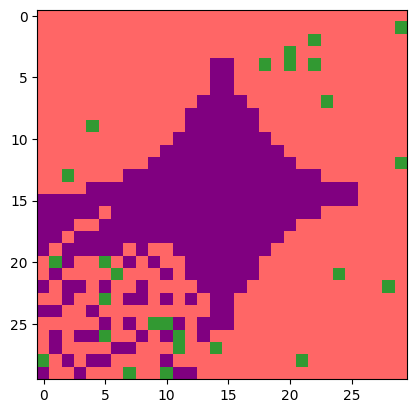

In [19]:
plot_Us(U_traditional[0])

compare mse and cos of the traditional battery to all batteries

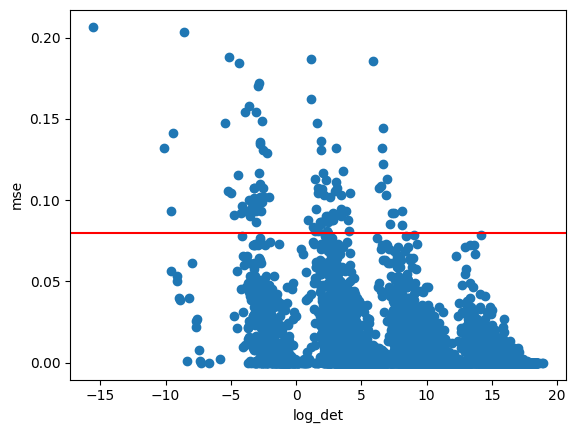

In [20]:
D_specific_offset = D[D['offset'] == 1e-2].reset_index(drop=True)
plt.scatter(D_specific_offset['log_det'], D_specific_offset['mse'])
plt.axhline(y=mse_trad, color='r', linestyle='-')
plt.xlabel('log_det')
plt.ylabel('mse')
plt.show()

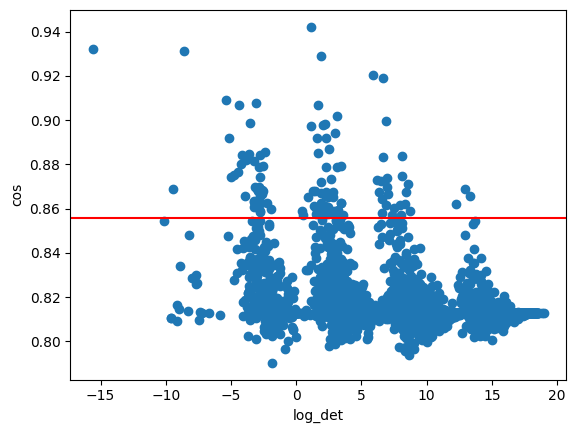

In [21]:
plt.scatter(D_specific_offset['log_det'], D_specific_offset['cos'])
plt.axhline(y=cos_trad, color='r', linestyle='-')
plt.xlabel('log_det')
plt.ylabel('cos')
plt.show()

plot the best and worst battery predicted by log_Det - seems like it gets the boundries of region 5 perfectly since it also gets the other parcels right

In [22]:
# find index of lowest mse_ols
max_log_det_idx = D_specific_offset['log_det'].idxmax()
min_log_det_idx = D_specific_offset['log_det'].idxmin()

print(min_log_det_idx)
print(max_log_det_idx)


9891
3515


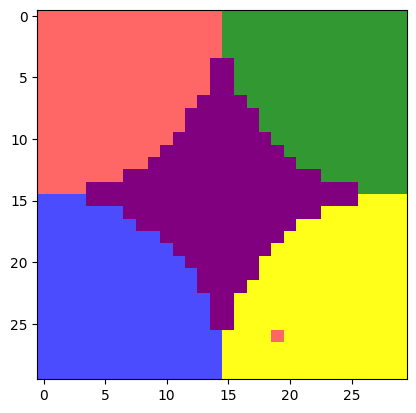

In [23]:
plot_Us(Us[max_log_det_idx][0])


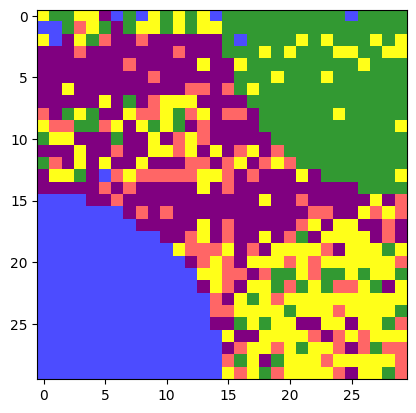

In [24]:
plot_Us(Us[min_log_det_idx][0])

# test the idea of thresholding for a single contrast, not simple task1>task2 contrast then threshold

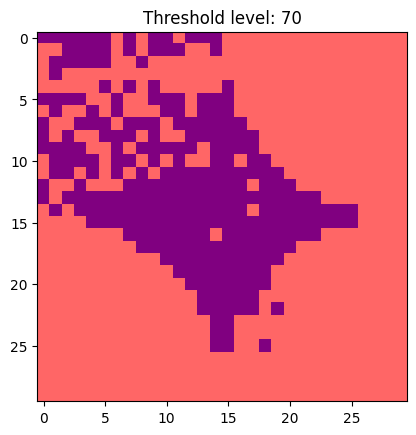

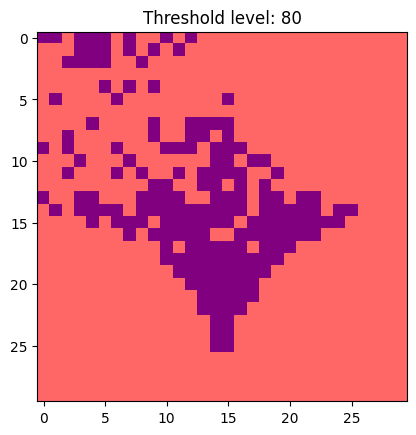

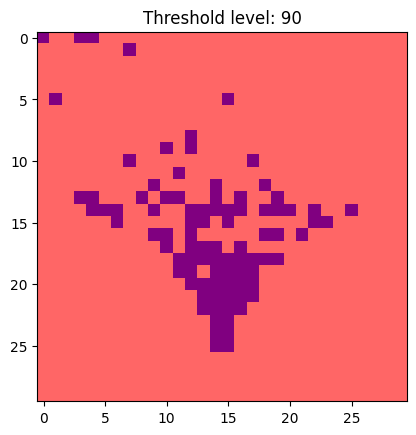

In [70]:
threshold_levels = [70, 80, 90]
# threshold_levels = np.arange(10, 100, 10)
U_tests = []
for level in threshold_levels:
    # Compute contrast
    contrast = Y_true_noisy[24, :] - Y_true_noisy[13, :]
    
    # Apply thresholding
    threshold = np.percentile(np.abs(contrast), level)
    thresholded_contrast = np.where(np.abs(contrast) > threshold, 1, 0)
    
    # Reshape and create U_test
    thresholded_contrast = thresholded_contrast.reshape((1, -1))
    U_test = np.zeros((4, 900))
    U_test = np.vstack((U_test, thresholded_contrast))
    
    # Append the result to the list
    U_tests.append(U_test)
    plt.figure()
    plot_Us(U_test,title=f'Threshold level: {level}')